In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

In [2]:
# --------------------------------------------
# 1. Load Data and Initial Analysis
# --------------------------------------------
df = pd.read_csv("OnlineNewsPopularity.csv")
df.columns = df.columns.str.strip()  # Clean up any leading/trailing whitespace in column names
display(df.head())

# Drop URL and timedelta columns
df_cleaned = df.drop(columns=[col for col in ['url', 'timedelta'] if col in df.columns])
display(df_cleaned.head())

# Remove extreme outliers (top 1%)
df_cleaned = df_cleaned[df_cleaned['shares'] < df_cleaned['shares'].quantile(0.99)]
display(df_cleaned.head())

display(df_cleaned.shape)

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,0.0,4.680365,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,0.0,4.913725,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,0.0,4.393365,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,0.0,4.404896,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,0.0,4.682836,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,0.0,4.680365,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,0.0,4.913725,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,0.0,4.393365,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,0.0,4.404896,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,0.0,4.682836,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


(39247, 59)

In [10]:
# --------------------------------------------
# 2. Feature Selection + Transformation + Scaling Pipeline
# --------------------------------------------
def prepare_data_pipeline(df, target_type='log', corr_threshold=0.05, test_size=0.2, random_state=42):
    if target_type == 'log':
        df = df.copy()
        df['target'] = np.log1p(df['shares'])
    elif target_type == 'sqrt':
        df = df.copy()
        df['target'] = np.sqrt(df['shares'])
    else:
        raise ValueError("target_type must be 'log' or 'sqrt'")

    corr_matrix = df.corr()
    corr_target = corr_matrix['target'].abs()
    selected_features = corr_target[corr_target > corr_threshold].index.tolist()
    if 'target' in selected_features:
        selected_features.remove('target')

    X = df[selected_features]
    y = df['target']

    # display(X)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test, selected_features

print("\nSelected features for log-transformed target:")
print(prepare_data_pipeline(df_cleaned, 'log')[4])  # selected_features is at index 4

print("\nSelected features for sqrt-transformed target:")
print(prepare_data_pipeline(df_cleaned, 'sqrt')[4])



Selected features for log-transformed target:
['num_hrefs', 'num_imgs', 'num_keywords', 'data_channel_is_entertainment', 'data_channel_is_socmed', 'data_channel_is_tech', 'data_channel_is_world', 'kw_min_avg', 'kw_max_avg', 'kw_avg_avg', 'self_reference_min_shares', 'self_reference_max_shares', 'self_reference_avg_sharess', 'weekday_is_saturday', 'weekday_is_sunday', 'is_weekend', 'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04', 'global_subjectivity', 'global_sentiment_polarity', 'rate_negative_words', 'title_sentiment_polarity', 'abs_title_sentiment_polarity', 'shares']

Selected features for sqrt-transformed target:
['num_hrefs', 'num_imgs', 'num_keywords', 'data_channel_is_entertainment', 'data_channel_is_socmed', 'data_channel_is_world', 'kw_avg_max', 'kw_min_avg', 'kw_max_avg', 'kw_avg_avg', 'self_reference_min_shares', 'self_reference_max_shares', 'self_reference_avg_sharess', 'weekday_is_saturday', 'weekday_is_sunday', 'is_weekend', 'LDA_02', 'LDA_03', 'global_subjectivity', 'abs_title_

In [4]:
# --------------------------------------------
# 3. Model Training and Evaluation
# --------------------------------------------
def train_and_evaluate(X_train, X_test, y_train, y_test, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return {
        'r2': r2_score(y_test, y_pred),
        'mae': mean_absolute_error(y_test, y_pred),
        'rmse': root_mean_squared_error(y_test, y_pred),
        'y_pred': y_pred
    }

In [5]:
# --------------------------------------------
# 4. Hyperparameter Tuning for Tree & MLP Models
# --------------------------------------------
def tune_model(model, param_grid, X_train, y_train):
    grid = GridSearchCV(model, param_grid, cv=3, scoring='r2', n_jobs=-1)
    grid.fit(X_train, y_train)
    return grid.best_estimator_

In [6]:
# --------------------------------------------
# 5. Apply on Both Transformations
# --------------------------------------------
base_models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(random_state=42),
    'GradientBoosting': GradientBoostingRegressor(random_state=42),
    'MLP': MLPRegressor(random_state=42, max_iter=1000)
}

param_grids = {
    'RandomForest': {
        'n_estimators': [100],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    },
    'GradientBoosting': {
        'n_estimators': [100],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5],
        'min_samples_leaf': [1, 2]
    },
    'MLP': {
        'hidden_layer_sizes': [(100,), (100, 50)],
        'activation': ['relu'],
        'alpha': [0.0001, 0.001]
    }
}

results_log, results_sqrt = {}, {}

X_train_log, X_test_log, y_train_log, y_test_log, _ = prepare_data_pipeline(df_cleaned, 'log')
X_train_sqrt, X_test_sqrt, y_train_sqrt, y_test_sqrt, _ = prepare_data_pipeline(df_cleaned, 'sqrt')

for name, model in base_models.items():
    if name in param_grids:
        tuned_model_log = tune_model(model, param_grids[name], X_train_log, y_train_log)
        tuned_model_sqrt = tune_model(model, param_grids[name], X_train_sqrt, y_train_sqrt)
    else:
        tuned_model_log = model
        tuned_model_sqrt = model

    # results_log[name] = train_and_evaluate()

    results_log[name] = train_and_evaluate(X_train_log, X_test_log, y_train_log, y_test_log, tuned_model_log)
    results_sqrt[name] = train_and_evaluate(X_train_sqrt, X_test_sqrt, y_train_sqrt, y_test_sqrt, tuned_model_sqrt)

In [7]:
from sklearn.model_selection import cross_val_score

def cross_val_vs_test(models, X_train, X_test, y_train, y_test):
    report = []
    for name, model in models.items():
        # Cross-validation score
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
        cv_mean = np.mean(cv_scores)
        
        # Fit on training data
        model.fit(X_train, y_train)
        
        # Test score
        test_r2 = r2_score(y_test, model.predict(X_test))
        
        report.append({
            'Model': name,
            'CV R2 (mean)': round(cv_mean, 5),
            'Test R2': round(test_r2, 5),
            'Gap': round(cv_mean - test_r2, 5)
        })
    
    return pd.DataFrame(report)

# Cross-validation vs test performance for log-transformed target
print("\n--- Log Transformed Target ---")
cv_test_log = cross_val_vs_test(base_models, X_train_log, X_test_log, y_train_log, y_test_log)
print(cv_test_log)

# Cross-validation vs test performance for sqrt-transformed target
print("\n--- Sqrt Transformed Target ---")
cv_test_sqrt = cross_val_vs_test(base_models, X_train_sqrt, X_test_sqrt, y_train_sqrt, y_test_sqrt)
print(cv_test_sqrt)



--- Log Transformed Target ---
              Model  CV R2 (mean)  Test R2      Gap
0  LinearRegression       0.72785  0.72205  0.00581
1      RandomForest       0.99964  0.99993 -0.00029
2  GradientBoosting       0.99980  0.99985 -0.00005
3               MLP       0.99460  0.99500 -0.00041

--- Sqrt Transformed Target ---
              Model  CV R2 (mean)  Test R2      Gap
0  LinearRegression       0.92934  0.92798  0.00136
1      RandomForest       1.00000  1.00000 -0.00000
2  GradientBoosting       0.99995  0.99995  0.00000
3               MLP       0.99986  0.99991 -0.00005


In [8]:
# --------------------------------------------
# 6. Compare Results
# --------------------------------------------
df_log = pd.DataFrame(results_log).T.drop(columns='y_pred')
df_sqrt = pd.DataFrame(results_sqrt).T.drop(columns='y_pred')

print("Performance on Log-Transformed Target:")
print(df_log)

print("\nPerformance on Sqrt-Transformed Target:")
print(df_sqrt)


Performance on Log-Transformed Target:
                        r2       mae      rmse
LinearRegression  0.722046  0.344633  0.461729
RandomForest      0.999933  0.000257  0.007193
GradientBoosting  0.999966  0.000896  0.005099
MLP               0.994341  0.030403  0.065883

Performance on Sqrt-Transformed Target:
                        r2       mae      rmse
LinearRegression  0.927982  4.976368  6.594499
RandomForest      0.999999  0.002388  0.026583
GradientBoosting  0.999997   0.01533  0.039976
MLP               0.999895  0.131918  0.251462


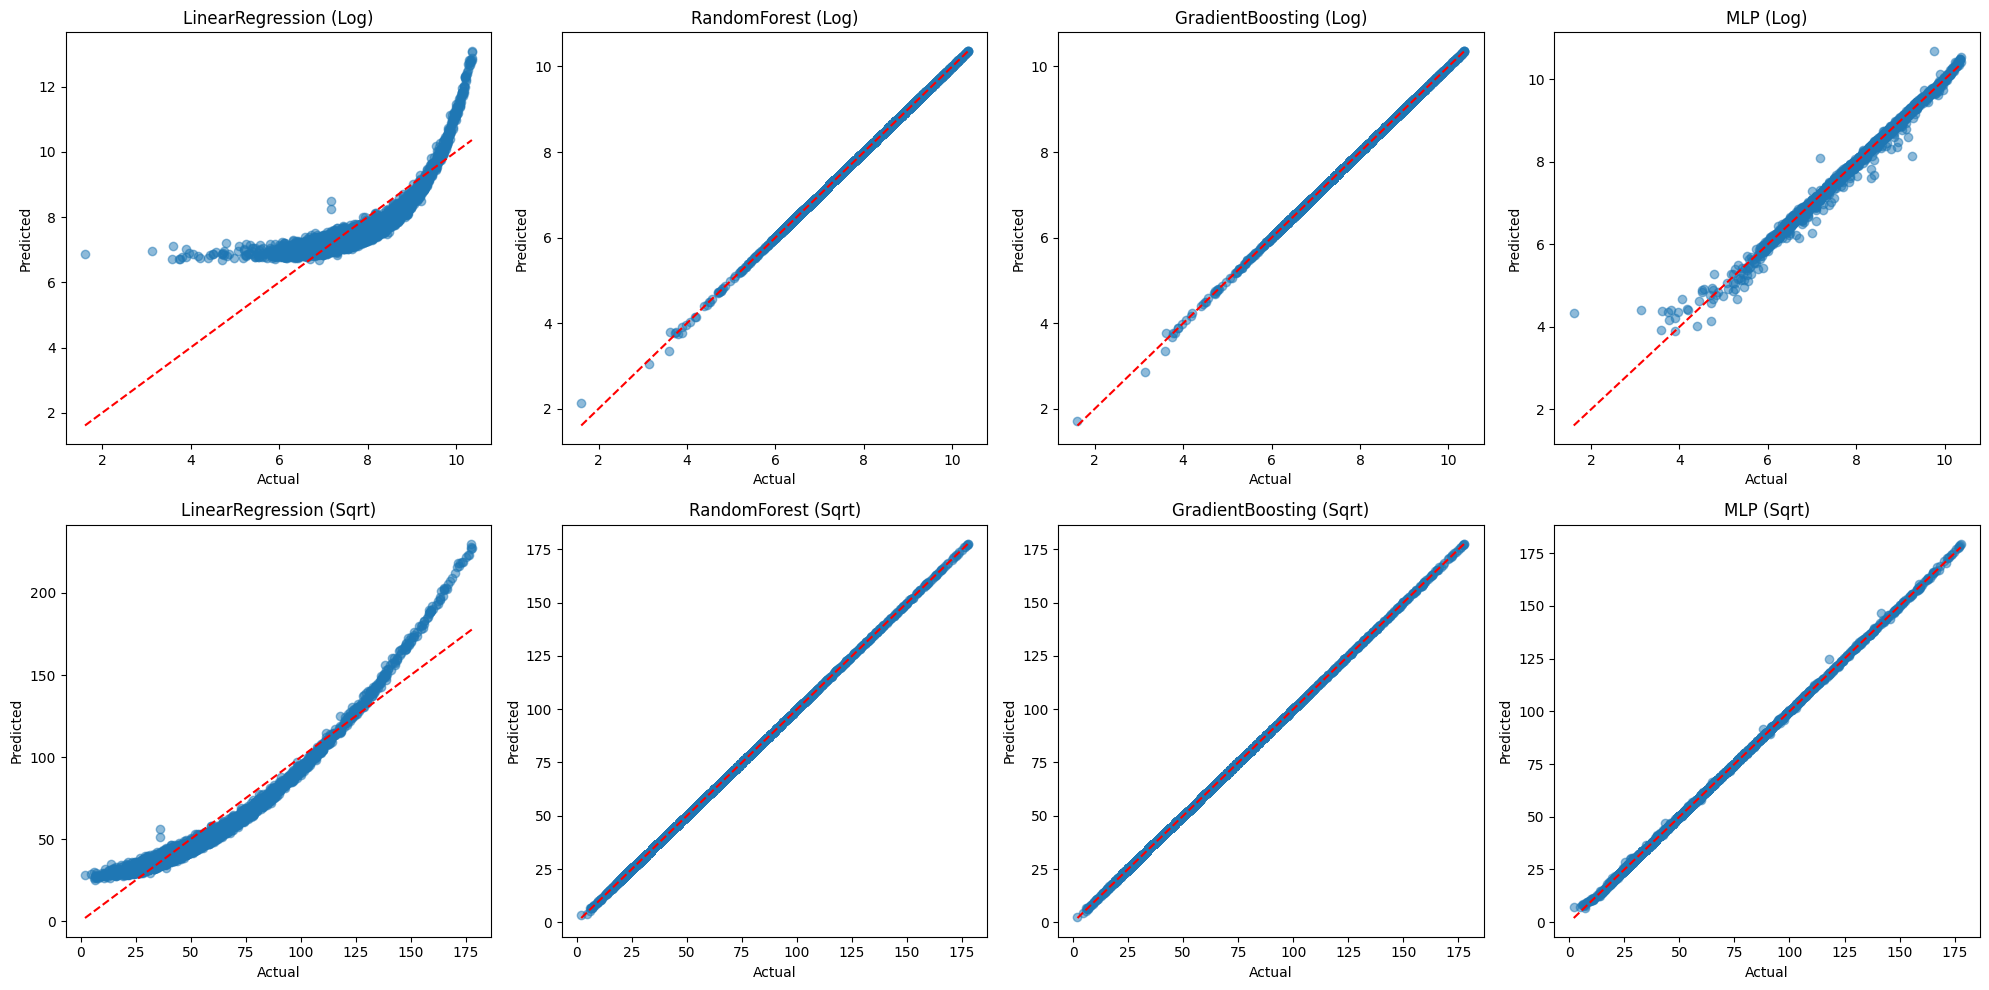

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for i, (name, result) in enumerate(results_log.items()):
    axes[0, i].scatter(y_test_log, result['y_pred'], alpha=0.5)
    axes[0, i].plot([y_test_log.min(), y_test_log.max()], [y_test_log.min(), y_test_log.max()], 'r--')
    axes[0, i].set_title(f'{name} (Log)')
    axes[0, i].set_xlabel('Actual')
    axes[0, i].set_ylabel('Predicted')

for i, (name, result) in enumerate(results_sqrt.items()):
    axes[1, i].scatter(y_test_sqrt, result['y_pred'], alpha=0.5)
    axes[1, i].plot([y_test_sqrt.min(), y_test_sqrt.max()], [y_test_sqrt.min(), y_test_sqrt.max()], 'r--')
    axes[1, i].set_title(f'{name} (Sqrt)')
    axes[1, i].set_xlabel('Actual')
    axes[1, i].set_ylabel('Predicted')

plt.tight_layout()
plt.show()